# **POSTTEST 5 Kecerdasan Buatan A1'23**
---
Nama: Muhammad Arya Fayyadh Razan  
NIM: 2309106010  
Kelas: A1'23  
Dataset: Indonesian Food and Drink Nutrition Dataset  
Link dataset: https://www.kaggle.com/datasets/anasfikrihanif/indonesian-food-and-drink-nutrition-dataset

# Library yang digunakan untuk EDA

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h4>1. Tampilkan rata-rata, standar deviasi, nilai minimum, nilai maksimum, Q1 Q2, dan Q3 dari attribute bertipe angka.

In [95]:
df = pd.read_csv('nutrition.csv')
df.describe()

,id,calories,proteins,fat,carbohydrate
count,1346.000000,1346.000000,1346.000000,1346.000000,1346.000000
mean,673.500000,203.217385,10.001189,7.584027,25.390193
std,388.701042,163.075430,11.847980,13.733063,32.193054
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,337.250000,75.000000,1.800000,0.500000,4.525000
50%,673.500000,146.000000,5.000000,2.000000,13.300000
75%,1009.750000,333.750000,15.000000,8.275000,37.575000
max,1346.000000,940.000000,83.000000,100.000000,647.000000


<h4>2. Tampilkan 10 record pertama dari dataset dengan attribute bertipe angka.

In [96]:
display(df.select_dtypes(include=['number']).head(10))

,id,calories,proteins,fat,carbohydrate
0,1,280.0,9.2,28.4,0.0
1,2,513.0,23.7,37.0,21.3
2,3,0.0,0.0,0.2,0.0
3,4,45.0,1.1,0.4,10.8
4,5,37.0,4.4,0.5,3.8
5,6,85.0,0.9,6.5,7.7
6,7,96.0,3.7,0.6,19.1
7,8,414.0,26.6,18.3,41.3
8,9,75.0,4.1,2.1,10.7
9,10,67.0,5.0,2.1,8.1


<h4>3. Tampilkan informasi jumlah record, jumlah attribute, nama attribute, jumlah attribute dengan tipe angka.

Berdasarkan informasi tersebut, didapat bahwa jumlah record berjumlah 1346 record, jumlah atribut berjumlah 7, nama atribute terdapat nama kolom id, calories, proteins, fat, carbohydrate, name, dan image. Dan terakhir jumlah atribut bertipe angka berjumlah 5 atribut.

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1346 entries, 0 to 1345
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            1346 non-null   int64  
 1   calories      1346 non-null   float64
 2   proteins      1346 non-null   float64
 3   fat           1346 non-null   float64
 4   carbohydrate  1346 non-null   float64
 5   name          1346 non-null   object 
 6   image         1346 non-null   object 
dtypes: float64(4), int64(1), object(2)
memory usage: 73.7+ KB


In [98]:
print(f"Jumlah record: {df.shape[0]}")
print(f"Jumlah attribute: {df.shape[1]}")
print(f"Nama attribute: {df.columns.tolist()}")
print(f"Jumlah attribute dengan tipe angka: {len(df.select_dtypes(include=['number']).columns)}")

Jumlah record: 1346
Jumlah attribute: 7
Nama attribute: ['id', 'calories', 'proteins', 'fat', 'carbohydrate', 'name', 'image']
Jumlah attribute dengan tipe angka: 5


<h4>4. Tampilkan jumlah label dari semua attribute yang bernilai object.

Berdasarkan informasi tersebut, jumlah label dari atribute yang bernilai object yaitu name berjumlah 1346 dan image berjumlah 1307.

In [99]:
print(df.select_dtypes(include=['object']).nunique())

name     1346
image    1307
dtype: int64


<h4>5. Visualisasikan dataset dengan salah satu grafik yaitu histogram.

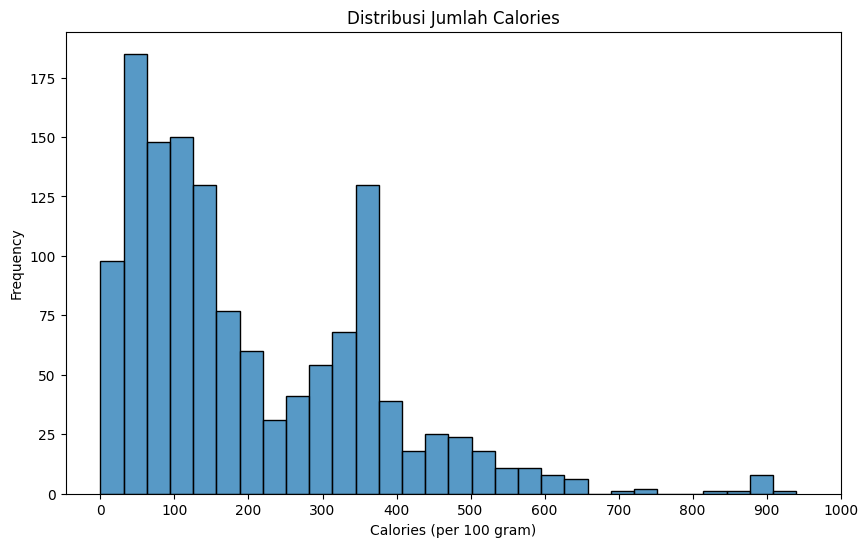

In [100]:
plt.figure(figsize=(10, 6))
sns.histplot(df['calories'], bins=30)
plt.title('Distribusi Jumlah Calories')
plt.xlabel('Calories (per 100 gram)')
plt.ylabel('Frequency')
plt.xticks(range(0, 1001, 100))
plt.show()

<h4>6. Tampilkan korelasi dataset menggunakan heatmap.

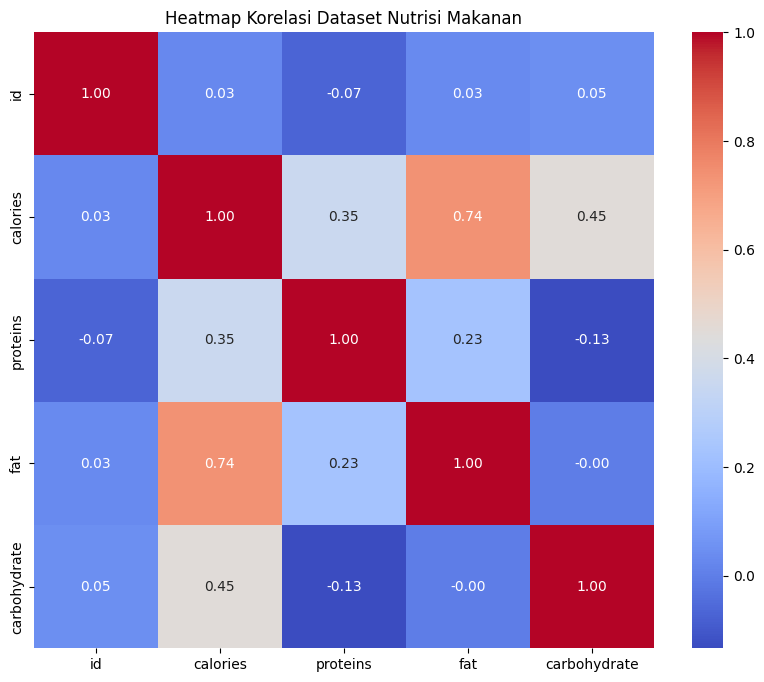

In [101]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Dataset Nutrisi Makanan')
plt.show()

<h4>7. Kesimpulan dari hasil analisis dan visualisasi data.

Berdasarkan hasil analisis, dataset berisi informasi nutrisi makanan per 100 gram dengan kolom ```calories``` yaitu jumlah energi/kalori, ```protein, fat, carbohydrate``` yaitu kandungan gizi utama. Rentang kalori yaitu dari 0-940 kcal per gram.

Berdasarkan visualisasi histogram, mayoritas makanan yang ada di dataset berada pada kisaran di bawah 200 kcal dengan puncak tertinggi berada di 50 kcal, sedangkan hanya sebagian kecil makanan yang berada pada di atas 400 kcal.

Berdasarkan hasil visualisasi heatmap menunjukkan bahwa kalori memiliki korelasi paling kuat dengan lemak (0.74) yang artinya, kandungan lemak paling berpengaruh terhadap jumlah kalori makanan. Makanan berlemak cenderung padat kalori, sedangkan makanan berprotein dan berkarbohidrat bervariasi dalam kontribusi kalori.

Untuk langkah selanjutnya nanti, rencananya saya akan melakukan klasifikasi makanan berdasarkan tingkat kalori. Nilai kalori yang semula numerik akan diubah menjadi kategori, yaitu:
*   Rendah kalori: di bawah 100 kcal,
*   Sedang: 100–300 kcal,
*   Tinggi kalori: di atas 300 kcal.

sumber: https://www.sciencedirect.com/science/article/abs/pii/S0195666319300200

# **Data Preprocessing**

## Proses Data Cleaning  
Proses identifikasi, perbaikan, atau penghapusan data yang rusak, tidak akurat, atau tidak relevan dalam dataset. Tujuannya untuk meningkatkan kualitas data. Dengan melakukan handling missing value, duplicated value, dan outlier jika ada.

## Handling Missing Value
Pada proses ini, melakukan pemeriksaan apakah ada kolom data yang memiliki missing value.  
Dan hasilnya tidak ada missing value pada dataset ini.



In [102]:
import pandas as pd
df = pd.read_csv('nutrition.csv')
df.isnull().sum()

,0
id,0
calories,0
proteins,0
fat,0
carbohydrate,0
name,0
image,0


## Handling Duplicate Value
Pada proses ini, melakukan pemeriksaan apakah ada kolom data yang nilainya duplikat.  
Dan hasilnya tidak ada duplicate value pada dataset ini.

In [103]:
duplicate = df.duplicated().sum()
print(f"Jumlah data duplikat: {duplicate}")

Jumlah data duplikat: 0


## Handling Outlier
Pada proses ini dilakukan pengecekan outlier dengan boxplot.  
Dari hasil eksplorasi data, terlihat ada beberapa nilai kalori yang jauh lebih tinggi dibanding mayoritas. Dalam kasus ini, outlier tidak dihapus atau diubah karena memang merepresentasikan makanan dengan kalori sangat tinggi. Karena tujuan analisis adalah mengklasifikasikan kategori kalori (rendah, sedang, tinggi), nilai ekstrem justru penting untuk memperkuat kelas tinggi.



<Axes: ylabel='calories'>

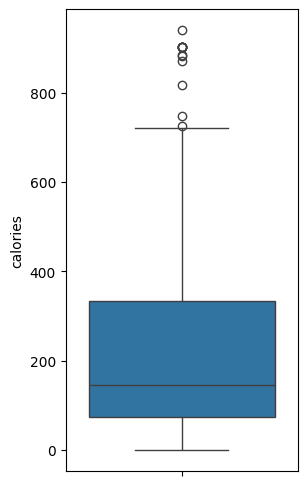

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(3,6))
sns.boxplot(df['calories'])

In [105]:
display(df.head())

,id,calories,proteins,fat,carbohydrate,name,image
0,1,280.0,9.2,28.4,0.0,Abon,https://img-cdn.medkomtek.com/PbrY9X3ignQ8sVuj...
1,2,513.0,23.7,37.0,21.3,Abon haruwan,https://img-global.cpcdn.com/recipes/cbf330fbd...
2,3,0.0,0.0,0.2,0.0,Agar-agar,https://res.cloudinary.com/dk0z4ums3/image/upl...
3,4,45.0,1.1,0.4,10.8,Akar tonjong segar,https://images.tokopedia.net/img/cache/200-squ...
4,5,37.0,4.4,0.5,3.8,Aletoge segar,https://nilaigizi.com/assets/images/produk/pro...


## Feature Engineering
Feature engineering dilakukan dengan menambahkan fitur baru bernama kategori_kalori yang dikategorikan berdasarkan nilai pada kolom Calories. Proses ini dilakukan dengan menentukan tiga kategori, yaitu Rendah (kalori < 100), Sedang (100–300), dan Tinggi (kalori > 300). Untuk kolom id, nama dan image didrop karena tidak diperlukan.

In [106]:
bins = [0, 100, 300, float('inf')]
labels = ['Rendah', 'Sedang', 'Tinggi']
df['kategori_kalori'] = pd.cut(df['calories'], bins=bins, labels=labels, right=False)
df.drop(['id', 'name', 'image'], axis=1, inplace=True)
display(df.head())

,calories,proteins,fat,carbohydrate,kategori_kalori
0,280.0,9.2,28.4,0.0,Sedang
1,513.0,23.7,37.0,21.3,Tinggi
2,0.0,0.0,0.2,0.0,Rendah
3,45.0,1.1,0.4,10.8,Rendah
4,37.0,4.4,0.5,3.8,Rendah


## Encoding kolom kategorikal
Encoding kolom kategorikal dilakukan untuk mengubah kolom data kategorikal menjadi numerikal. Menggunakan Ordinal Encoding di mana setiap nilai kategori unik diberi nilai bilangan bulat. Mengubah kategori kalori rendah=0, sedang=1, tinggi=2.

In [107]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(categories=[['Rendah','Sedang','Tinggi']])
df['kategori_kalori'] = encoder.fit_transform(df[['kategori_kalori']])
display(df.head())

,calories,proteins,fat,carbohydrate,kategori_kalori
0,280.0,9.2,28.4,0.0,1.0
1,513.0,23.7,37.0,21.3,2.0
2,0.0,0.0,0.2,0.0,0.0
3,45.0,1.1,0.4,10.8,0.0
4,37.0,4.4,0.5,3.8,0.0


## Normalisasi/standarisasi kolom numerik
Tahap ini dilakukan standarisasi. Standarisasi digunakan untuk menyamakan skala antar fitur numerik agar model tidak bias terhadap fitur dengan rentang nilai besar, seperti lemak atau karbohidrat yang bisa jauh lebih tinggi dibanding protein. Metode Z-Score Scaling (StandardScaler) mengubah nilai data menjadi selisih terhadap rata-rata yang dibagi standar deviasi, sehingga data memiliki rata-rata 0 dan standar deviasi 1.

In [108]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Tentukan fitur numerik (tanpa target)
feature_cols = ["calories", "proteins", "fat", "carbohydrate"]
target_col = "kategori_kalori"

# Inisialisasi scaler
scaler = StandardScaler()

# Fit dan transform hanya fitur
scaled_features = scaler.fit_transform(df[feature_cols])

# Buat DataFrame hasil standarisasi
df_scaled = pd.DataFrame(scaled_features, columns=feature_cols)

# Gabungkan kembali dengan target asli (0,1,2)
df_final = pd.concat([df_scaled, df[target_col]], axis=1)

df_final.head()

,calories,proteins,fat,carbohydrate,kategori_kalori
0,0.471016,-0.067648,1.516319,-0.788979,1.0
1,1.900334,1.156645,2.142778,-0.127099,2.0
2,-1.246619,-0.844440,-0.537882,-0.788979,0.0
3,-0.970570,-0.751562,-0.523313,-0.453378,0.0
4,-1.019646,-0.472930,-0.516029,-0.670897,0.0


## Splitting data ke dalam data training dan data testing
Splittin data dapat digunakan untuk mengevaluasi performa model machine learning dan mengurangi terjadinya overfitting. Metode ini membagi dataset menjadi dua bagian atau lebih yang membentuk sub himpunan data. Di sini data akan displit menjadi train 80% dan test 20%.  
X = fitur (protein, fat, carbohydrate, calories)  
y = target (kategori_kalori yang sudah distandarisasi)

In [109]:
from sklearn.model_selection import train_test_split

# Fitur (X) dan target (y)
X = df_final.drop(columns=["kategori_kalori"])
y = df_final["kategori_kalori"]

# Bagi data menjadi train dan test (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Dimensi X_train:", X_train.shape)
print("Dimensi X_test:", X_test.shape)
print("Dimensi y_train:", y_train.shape)
print("Dimensi y_test:", y_test.shape)


Dimensi X_train: (1076, 4)
Dimensi X_test: (270, 4)
Dimensi y_train: (1076,)
Dimensi y_test: (270,)


## Implementasi Metode: Support Vector Classifier (Klasifikasi)  
Model Support Vector Classifier (SVC) digunakan untuk melakukan supervised learning pada data dengan label kategorikal. Dalam konteks ini, model dilatih untuk mengklasifikasikan data makanan ke dalam kategori kalori tertentu (misalnya “rendah”, “sedang”, atau “tinggi”).
Model akan belajar dari 80% data training dan kemudian diuji menggunakan 20% data testing untuk mengevaluasi performanya.

In [110]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [111]:
svm = SVC(kernel="linear") # Buat objek classifier (model) SVM
svm.fit(X_train, y_train) # Latih classifier (model) dengan data train

SVC(kernel='linear')

## Evaluasi Hasil Prediksi  
Berdasarkan hasil confusion matrix, model SVM mampu mengklasifikasikan data kategori kalori dengan sangat baik.
Dari total 270 data uji, hampir semua data berhasil diprediksi dengan benar pada kelas rendah, sedang, dan tinggi.  
* Pada kelas rendah, terdapat 91 data yang diprediksi benar dan hanya 1 data yang salah diklasifikasikan.  
* Kelas sedang memperoleh hasil sempurna dengan 100 data benar tanpa kesalahan prediksi.  
* Kelas tinggi sedikit mengalami misklasifikasi sebanyak 3 data yang dikira sebagai kelas “sedang”.

Dari Classification Report, diperoleh hasil:  
* Accuracy sebesar 0.99 menandakan model memiliki tingkat ketepatan prediksi 99%.  
* Precision, Recall, dan F1-score untuk ketiga kelas juga sangat tinggi (rata-rata di atas 0.98).

Secara keseluruhan, model Support Vector Classifier (SVM) menunjukkan performa yang sangat baik dan stabil dalam mengklasifikasikan kategori kalori berdasarkan fitur nutrisi (kalori, protein, lemak, dan karbohidrat).
Nilai metrik yang tinggi menandakan bahwa model telah berhasil mempelajari pola data dengan baik tanpa overfitting yang berarti.

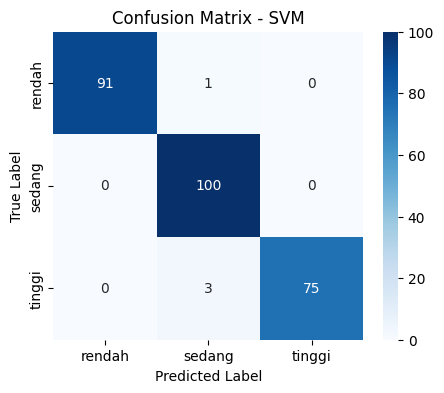

Classification Report:
               precision    recall  f1-score   support

      rendah       1.00      0.99      0.99        92
      sedang       0.96      1.00      0.98       100
      tinggi       1.00      0.96      0.98        78

    accuracy                           0.99       270
   macro avg       0.99      0.98      0.99       270
weighted avg       0.99      0.99      0.99       270



In [112]:
y_pred = svm.predict(X_test) # Lakukan prediksi data test dengan model

# Membuat confusion matrix
cm = confusion_matrix(y_test, y_pred)

label_names = ["rendah", "sedang", "tinggi"]

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d',
            xticklabels=label_names, yticklabels=label_names)
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Menampilkan classification report
report = classification_report(y_test, y_pred,
                               target_names=label_names)
print("Classification Report:\n", report)

## Visualisasi Hasil Prediksi  
Dua jenis visualisasi dibuat untuk memahami performa model klasifikasi. Pie chart digunakan untuk menunjukkan distribusi proporsi tiap kategori kalori (rendah, sedang, tinggi) antara hasil aktual dan hasil prediksi.  

Sementara scatter plot memperlihatkan seberapa dekat hasil prediksi terhadap nilai aktual; semakin banyak titik yang mendekati garis diagonal, semakin baik akurasi model.

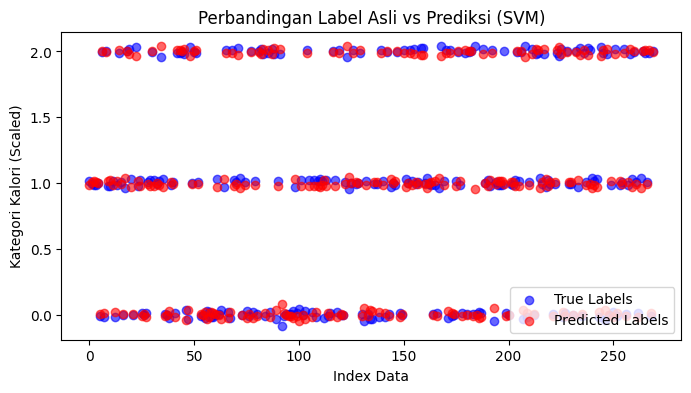

In [113]:
# SCATTER PLOT
jitter = np.random.normal(0, 0.02, len(y_test))

plt.figure(figsize=(8,4))
plt.scatter(range(len(y_test)), y_test + jitter, color='blue', label='True Labels', alpha=0.6)
plt.scatter(range(len(y_pred)), y_pred - jitter, color='red', label='Predicted Labels', alpha=0.6)
plt.title("Perbandingan Label Asli vs Prediksi (SVM)")
plt.xlabel("Index Data")
plt.ylabel("Kategori Kalori (Scaled)")
plt.legend()
plt.show()

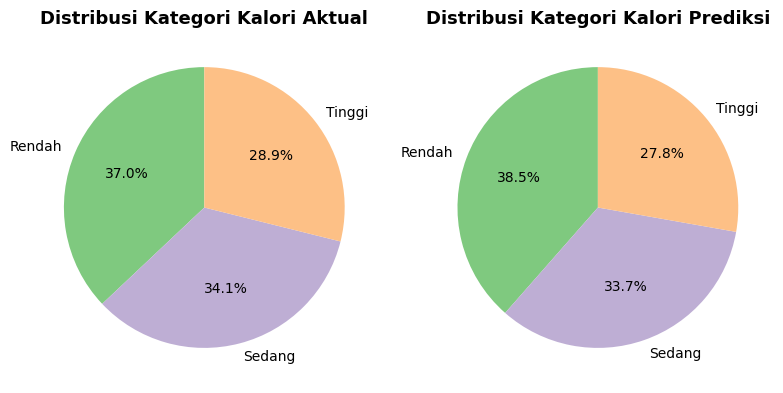

In [114]:
# PIE CHART
df_eval = pd.DataFrame({'Aktual': y_test, 'Prediksi': y_pred})
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Pie chart data aktual
df_eval['Aktual'].value_counts().plot.pie(
    autopct='%1.1f%%',
    ax=axes[0],
    startangle=90,
    colors=['#7fc97f','#beaed4','#fdc086'],
    textprops={'fontsize': 10},
    labels=['Rendah','Sedang','Tinggi']
)
axes[0].set_title('Distribusi Kategori Kalori Aktual', fontsize=13, fontweight='bold')
axes[0].set_ylabel('')

# Pie chart data prediksi
df_eval['Prediksi'].value_counts().plot.pie(
    autopct='%1.1f%%',
    ax=axes[1],
    startangle=90,
    colors=['#7fc97f','#beaed4','#fdc086'],
    textprops={'fontsize': 10},
    labels=['Rendah','Sedang','Tinggi']
)
axes[1].set_title('Distribusi Kategori Kalori Prediksi', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Pada scatter plot, titik berwarna biru (label aktual) dan merah (label prediksi) terlihat saling berdekatan, menandakan hasil prediksi model sangat mendekati nilai sebenarnya. Hal ini menunjukkan bahwa model memiliki kemampuan klasifikasi yang konsisten terhadap data uji.

Sedangkan pada pie chart, distribusi kategori kalori antara data aktual dan hasil prediksi juga hampir sama.
* Kategori Rendah: aktual 37.0%, prediksi 38.5% (selisih 1.5%)
* Kategori Sedang: aktual 34.1%, prediksi 33.7% (selisih 0.4%)
* Kategori Tinggi: aktual 28.9%, prediksi 27.8% (selisih 1.1%)

Dari kedua visualisasi di atas, dapat disimpulkan bahwa:

* Model SVM cukup efektif dalam memprediksi kategori kalori.
* Hasil prediksi mendekati label aktual baik secara titik individual maupun secara proporsi keseluruhan.
* Visualisasi ini mendukung bahwa model memiliki akurasi dan generalisasi yang baik terhadap data uji.

## Membuat Model Deep Learning DNN  
Membuat model DNN dengan 3 lapisan.
Lapisan Input layer dari arsitektur model menggunakan Dense layer berisi 32 unit, dengan aktivasi ReLU untuk menangani non-linearitas. Ukuran input ditentukan berdasarkan jumlah kolom fitur dalam data pelatihan, yaitu X_train.shape[1].  
Selanjutnya, model dilengkapi dengan lapisan tersembunyi kedua yang memiliki 16 unit neuron, juga menggunakan fungsi aktivasi ReLU, yang berperan dalam menangkap pola-pola kompleks dari representasi sebelumnya.  
Output layer menggunakan fungsi aktivasi ```activation=softmax``` karean ini adalah   
multiclass classification (kategori kalori: rendah=0, sedang=1, tinggi=2)

In [123]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Melakukan Kompilasi Model  
Melakukan kompilasi model. Menggunakan fungsi loss ```loss='sparse_categorical_crossentropy'``` karena target memiliki lebih dari 2 class yaitu 3 class dan juga telah diencode dengan menggunakan label encoder atau ordinal encoder. kategori kalori: rendah=0, sedang=1, tinggi=2

In [124]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [125]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739 (2.89 KB)

 Trainable params: 739 (2.89 KB)

 Non-trainable params: 0 (0.00 B)

## Training Model  
Melatih model terhadap data. Menggunakan data training (X_train, y_train) untuk melatih model. Kemudian juga menerapkan fungsi callback EarlyStopping untuk otomatis menghentikan pelatihan jika tidak ada peningkatan (misalnya pada val_loss) setelah beberapa epoch utuk mencegah overfitting.  
Epoch berhenti hingga 50 (sampai selesai). Model berhasil belajar dengan baik, memiliki stabilitas tinggi, dan konvergen pada nilai akurasi yang sangat tinggi (mendekati 99%).

In [126]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.6638 - loss: 0.9491 - val_accuracy: 0.7741 - val_loss: 0.7161
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7664 - loss: 0.6408 - val_accuracy: 0.8037 - val_loss: 0.4868
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8423 - loss: 0.4267 - val_accuracy: 0.8704 - val_loss: 0.3856
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9142 - loss: 0.3270 - val_accuracy: 0.9037 - val_loss: 0.3162
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9268 - loss: 0.2689 - val_accuracy: 0.9037 - val_loss: 0.2687
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9209 - loss: 0.2479 - val_accuracy: 0.9185 - val_loss: 0.2292
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9404 - loss: 0.1982 - val_accuracy: 0.9333 - val_loss: 0.2116
Epoch 8/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9540 - loss: 0.1611 - val_accuracy: 0.9519 - val_loss

## Visualisasi  

Validation accuracy  
Terlihat bahwa akurasi model meningkat tajam dari awal pelatihan hingga mencapai hampir 99% di akhir epoch.
Kurva training accuracy dan validation accuracy juga saling berdekatan, menandakan bahwa model tidak mengalami overfitting dan mampu melakukan generalisasi dengan baik terhadap data baru.


Loss accuracy  
Nilai loss (kesalahan prediksi) turun drastis dari awal hingga mendekati 0.04 pada akhir pelatihan.
Pola penurunan training loss dan validation loss yang serupa menunjukkan bahwa proses belajar berjalan stabil

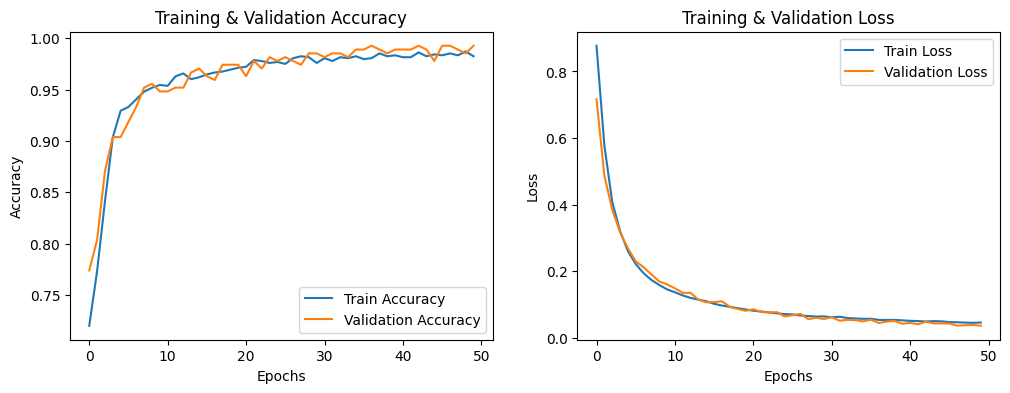

In [127]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


## Evaluasi Model  
Hasil evaluasi model menunjukkan akurasi 99.26%

In [129]:
model.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9896 - loss: 0.0319 


[0.03573564440011978, 0.9925925731658936]

In [121]:
model.save('ModelNutrisiPt5.keras')

In [122]:
new_model = tf.keras.models.load_model('ModelNutrisiPt5.keras')
new_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,219 (8.67 KB)

 Trainable params: 739 (2.89 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,480 (5.79 KB)